In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Walmart DataSet.csv')

In [4]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [5]:
df.dropna(inplace=True)

In [6]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

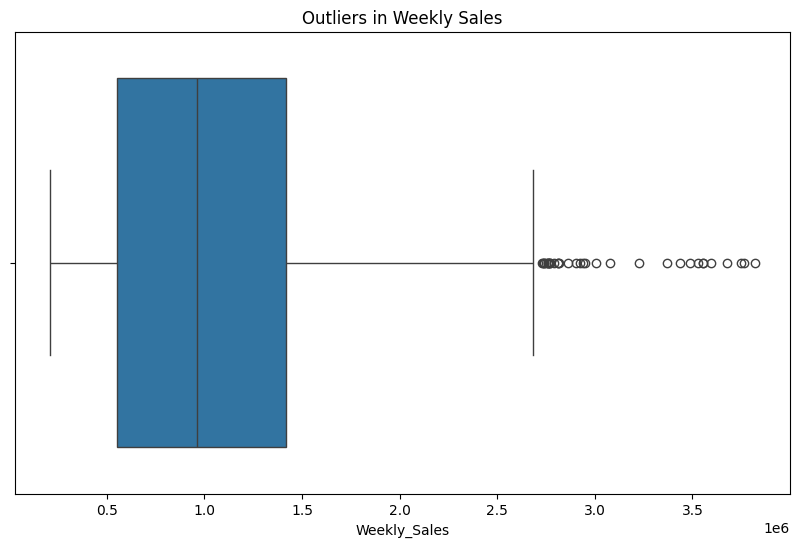

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Weekly_Sales'])
plt.title('Outliers in Weekly Sales')
plt.savefig('boxplot_sales.png')

In [8]:
# Calculate correlation between Weekly_Sales and Unemployment for each store
# We select every second row [0::2] because .corr() returns a matrix for each group
unemployment_corr = df.groupby('Store')[['Weekly_Sales', 'Unemployment']].corr().iloc[0::2, -1].reset_index()
unemployment_corr.columns = ['Store', 'level_1', 'Correlation']

In [9]:
# Sort to find stores with strongest negative correlation (suffering the most)
stores_suffering_unemployment = unemployment_corr.sort_values(by='Correlation')

In [10]:
# Aggregate weekly sales by Date to see the trend over time
seasonal_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

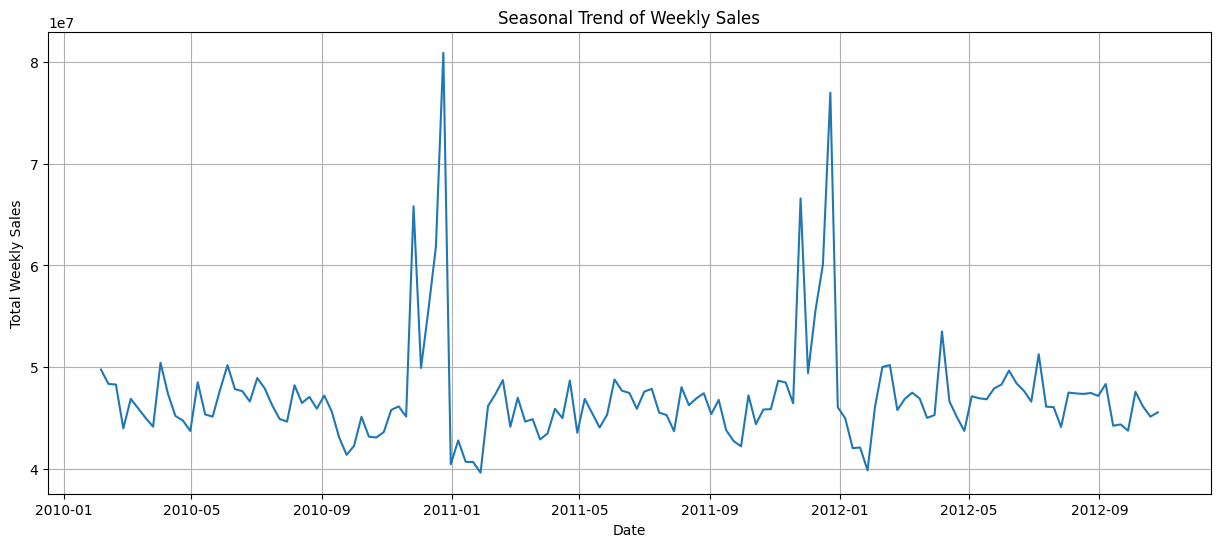

In [11]:
# Plot the trend
plt.figure(figsize=(15, 6))
plt.plot(seasonal_sales['Date'], seasonal_sales['Weekly_Sales'])
plt.title('Seasonal Trend of Weekly Sales')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales')
plt.grid(True)
plt.savefig('seasonal_trend.png')

In [12]:
# Calculate overall correlation
temp_correlation = df['Weekly_Sales'].corr(df['Temperature'])

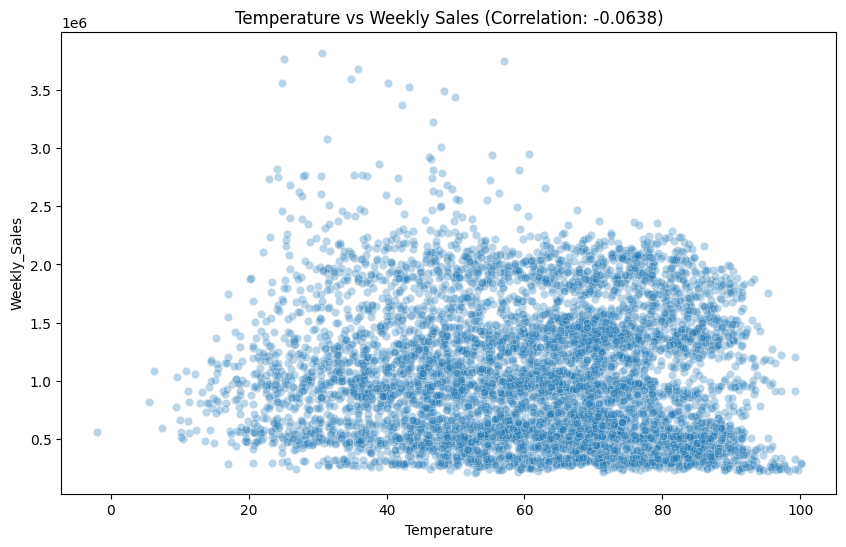

In [13]:
# Scatter plot to visualize
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df, alpha=0.3)
plt.title(f'Temperature vs Weekly Sales (Correlation: {temp_correlation:.4f})')
plt.savefig('temp_vs_sales.png')

In [14]:
# Calculate correlation between Weekly_Sales and CPI for each store
cpi_corr = df.groupby('Store')[['Weekly_Sales', 'CPI']].corr().iloc[0::2, -1].reset_index()
cpi_corr.columns = ['Store', 'level_1', 'Correlation']
# Sort to see how different stores are affected
cpi_affected_stores = cpi_corr.sort_values(by='Correlation')

In [15]:
# Sum sales by store and sort descending
total_sales_by_store = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
top_performing_store = total_sales_by_store.head(1)

In [16]:
# Worst Performing Store & Difference ---
worst_performing_store = total_sales_by_store.tail(1)

In [17]:
# Calculate difference
sales_difference = total_sales_by_store.iloc[0] - total_sales_by_store.iloc[-1]

In [41]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# Assuming 'Weekly_Sales' is the target variable and all other numerical columns are features
features = df.drop(['Weekly_Sales', 'Date'], axis=1) # Drop 'Date' as it's not a direct feature for this model type
target = df['Weekly_Sales']

x = features # Assign features to x
y = target # Assign target to y

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

**Sarima Model**

In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

In [19]:
warnings.filterwarnings("ignore")

In [21]:
#...dataframe to store forecasts
all_forecasts = pd.DataFrame()

In [24]:
# Get list of all unique stores
unique_stores = df['Store'].unique()


In [42]:
# Loop through each store
for store_id in unique_stores:
    # Filter data for the specific store
    store_data = df[df['Store'] == store_id].sort_values('Date')
    series = store_data.set_index('Date')['Weekly_Sales']
    #..SARIMA model with seasonal order (52 weeks)
    model = SARIMAX(series,
                    order=(1, 1, 1),
                    seasonal_order=(1, 1, 0, 52),
                    enforce_stationarity=False,
                    enforce_invertibility=False)

    # Fit the model
    model_fit = model.fit(disp=False)

    #Forecast for the next 12 weeks
    forecast = model_fit.get_forecast(steps=12)
    forecast_values = forecast.predicted_mean

    # Format the result
    temp_df = pd.DataFrame({
                'Store': store_id,
                'Date': forecast_values.index,
                'Weekly_Sales_Forecast': forecast_values.values
            })

    # Append to the main dataframe
    try:
        all_forecasts = pd.concat([all_forecasts, temp_df])
        print(f"Store {store_id} forecast complete.")
    except Exception as e:
        print(f"Failed to forecast for Store {store_id}: {e}")

print("All store forecasts generated.")

Store 1 forecast complete.
Store 2 forecast complete.
Store 3 forecast complete.
Store 4 forecast complete.
Store 5 forecast complete.
Store 6 forecast complete.
Store 7 forecast complete.
Store 8 forecast complete.
Store 9 forecast complete.
Store 10 forecast complete.
Store 11 forecast complete.
Store 12 forecast complete.
Store 13 forecast complete.
Store 14 forecast complete.
Store 15 forecast complete.
Store 16 forecast complete.
Store 17 forecast complete.
Store 18 forecast complete.
Store 19 forecast complete.
Store 20 forecast complete.
Store 21 forecast complete.
Store 22 forecast complete.
Store 23 forecast complete.
Store 24 forecast complete.
Store 25 forecast complete.
Store 26 forecast complete.
Store 27 forecast complete.
Store 28 forecast complete.
Store 29 forecast complete.
Store 30 forecast complete.
Store 31 forecast complete.
Store 32 forecast complete.
Store 33 forecast complete.
Store 34 forecast complete.
Store 35 forecast complete.
Store 36 forecast complete.
S

In [47]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [51]:
# Calculate Metrics

store_id_for_eval = unique_stores[0] # Get the first store ID

# Get the historical series for this store
eval_series = df[df['Store'] == store_id_for_eval].sort_values('Date').set_index('Date')['Weekly_Sales']

# Split into training and test sets (e.g., last 12 weeks for testing)
# Ensure there's enough data for both training and testing
if len(eval_series) > 24: # Need at least 24 weeks for a 12-week test and some training
    train_eval_series = eval_series[:-12]
    test = eval_series[-12:]

    # Retrain SARIMA model on the training part of this store's data for evaluation
    eval_model = SARIMAX(train_eval_series,
                    order=(1, 1, 1),
                    seasonal_order=(1, 1, 0, 52),
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    eval_model_fit = eval_model.fit(disp=False)

    # Generate predictions for the test period
    predictions = eval_model_fit.predict(start=test.index[0], end=test.index[-1], typ='levels')

    # Ensure 'predictions' has the same index as 'test' for metric calculation
    predictions = predictions.reindex(test.index)

    # Calculate Metrics
    mae = mean_absolute_error(test, predictions)
    rmse = np.sqrt(mean_squared_error(test, predictions))
    mape = np.mean(np.abs((test - predictions) / test)) * 100
    accuracy = 100 - mape

    print(f"Evaluation Metrics for Store {store_id_for_eval} (last 12 weeks):")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"Accuracy: {accuracy:.2f}%")
else:
    print(f"Not enough data for Store {store_id_for_eval} to perform a 12-week backtesting evaluation.")

# The all_forecasts DataFrame still holds the future 12-week forecasts for all stores.
# This metric calculation is separate for model performance assessment.

Evaluation Metrics for Store 1 (last 12 weeks):
MAE: 41927.99
RMSE: 47258.60
MAPE: 2.73%
Accuracy: 97.27%


In [54]:
# Refit model on the entire dataset to forecast into the unknown future
final_model = SARIMAX(series,
                      order=(1, 1, 1),
                      seasonal_order=(1, 1, 0, 52),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
final_model_fit = final_model.fit(disp=False)
future_forecast = final_model_fit.get_forecast(steps=12)
forecast_values = future_forecast.predicted_mean

In [56]:
# 6. Visualize Results
plt.figure(figsize=(14, 7))

<Figure size 1400x700 with 0 Axes>

<Figure size 1400x700 with 0 Axes>

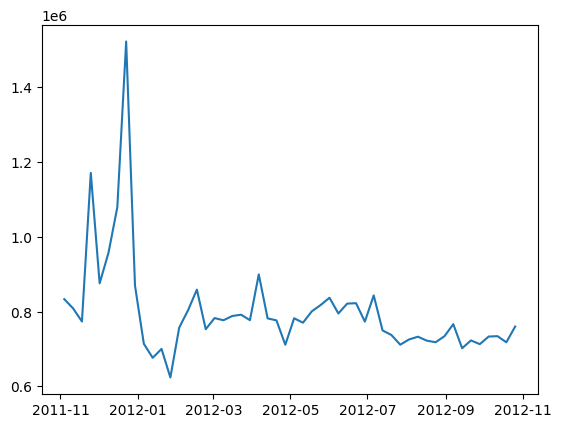

In [58]:
# Plot historical data (last 1 year for clarity)
plt.plot(series.index[-52:], series.values[-52:], label='Historical Sales (Last Year)')

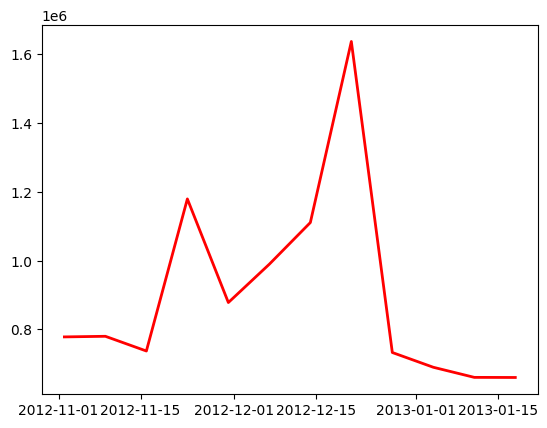

In [59]:
plt.plot(forecast_values.index, forecast_values, label='Future 12-Week Forecast', color='red', linewidth=2)

# Task
Consolidate the SARIMA model definition, fitting, and forecasting steps for each store into a single code cell to ensure all stores are processed correctly.

## Consolidate_SARIMA_Loop

### Subtask:
Consolidate the SARIMA model definition, fitting, and forecasting steps for each store into a single code cell to ensure all stores are processed correctly.


## Summary:

The provided solving process only describes the task of consolidating the SARIMA model definition, fitting, and forecasting steps for each store into a single code cell. It does not contain any execution details, results, or findings from performing this consolidation. Therefore, I cannot extract any key findings or insights.
